PCA RESULTS:
Explained Variance by PC1: 32.56%
Explained Variance by PC2: 17.32%
Total Variance Explained: 49.88%


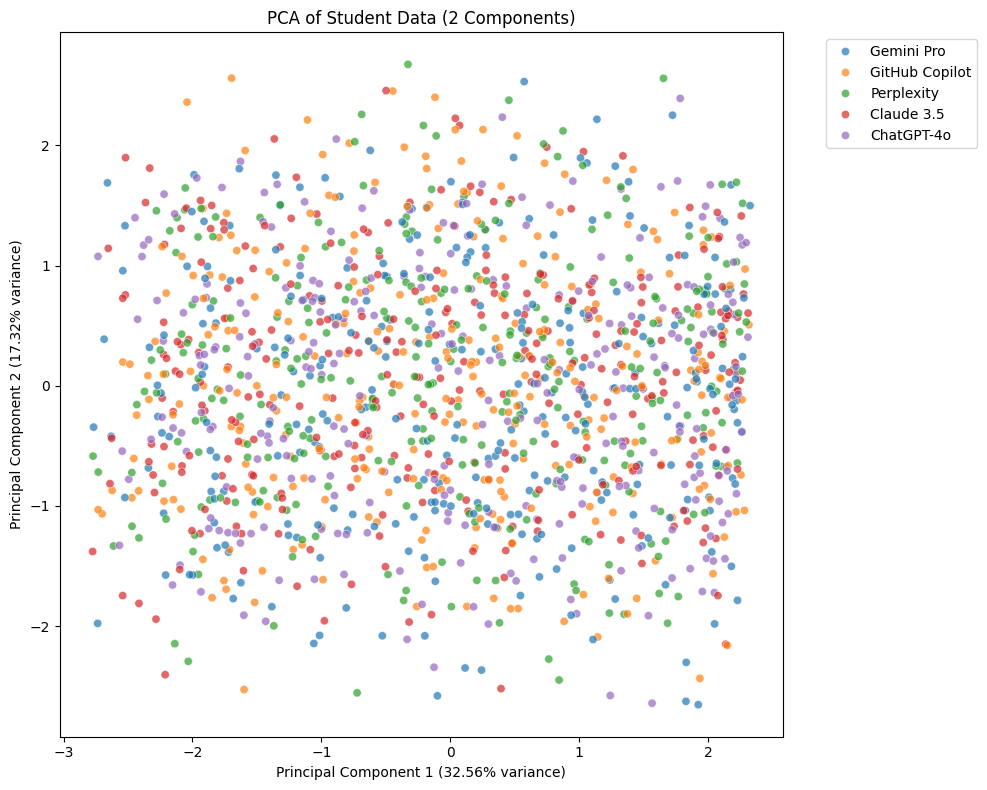

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load the student dataset
df = pd.read_csv('AI_Impact_Student_Life_2026.csv')

# 1. Select the numerical columns to perform PCA on
num_cols = ['Age', 'Task_Frequency_Daily', 'GPA_Baseline', 'GPA_Post_AI', 'Time_Saved_Hours_Weekly', 'Career_Confidence_Score']
X_num = df[num_cols]

# 2. Standardize the data (crucial for PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# 3. Run PCA (let's start with 2 components for 2D visualization)
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

# 4. Get the explained variance
explained_var = pca.explained_variance_ratio_

# 5. Create a DataFrame for plotting
pc_df = pd.DataFrame(data=pcs, columns=['PC1', 'PC2'])
pc_df['AI_Tool'] = df['Primary_AI_Tool'] # Add a categorical column to color the dots

# 6. Plot the results
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='AI_Tool', data=pc_df, alpha=0.7)
plt.title('PCA of Student Data (2 Components)')
plt.xlabel(f'Principal Component 1 ({explained_var[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_var[1]*100:.2f}% variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pca_student_tools.png')

print("PCA RESULTS:")
print(f"Explained Variance by PC1: {explained_var[0]*100:.2f}%")
print(f"Explained Variance by PC2: {explained_var[1]*100:.2f}%")
print(f"Total Variance Explained: {(explained_var[0] + explained_var[1])*100:.2f}%")

In [4]:
#Let's try some model adequacy tests.
import pandas as pd
import numpy as np
from scipy.stats import chi2

# Load the student dataset
df = pd.read_csv('AI_Impact_Student_Life_2026.csv')

# Select the numerical columns
num_cols = ['Age', 'Task_Frequency_Daily', 'GPA_Baseline', 'GPA_Post_AI', 'Time_Saved_Hours_Weekly', 'Career_Confidence_Score']
X_num = df[num_cols]

# 1. Correlation Matrix
R = X_num.corr().values
n = X_num.shape[0]
p = X_num.shape[1]

# 2. Bartlett's Test of Sphericity
# Checks if the correlation matrix is an identity matrix (no correlation between variables)
det_R = np.linalg.det(R)
chi2_stat = - (n - 1 - (2*p + 5)/6) * np.log(det_R)
df_chi2 = p * (p - 1) / 2
p_value = chi2.sf(chi2_stat, df_chi2)

print("--- Bartlett's Test of Sphericity ---")
print(f"Chi-Square: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# 3. Kaiser-Meyer-Olkin (KMO) Test
# Measures the proportion of variance among variables that might be common variance
# Inverse of correlation matrix
try:
    V = np.linalg.inv(R)
    # Partial correlation matrix Q
    Q = np.zeros((p, p))
    for i in range(p):
        for j in range(p):
            if i != j:
                Q[i, j] = -V[i, j] / np.sqrt(V[i, i] * V[j, j])

    # KMO Formula: sum(r^2) / (sum(r^2) + sum(q^2)) for off-diagonal elements
    r_sq_sum = np.sum(R**2) - p # subtract the diagonal 1s
    q_sq_sum = np.sum(Q**2)
    kmo_stat = r_sq_sum / (r_sq_sum + q_sq_sum)

    print("\n--- Kaiser-Meyer-Olkin (KMO) Test ---")
    print(f"KMO Statistic: {kmo_stat:.4f}")
except Exception as e:
    print(f"\nError computing KMO: {e}")

--- Bartlett's Test of Sphericity ---
Chi-Square: 3546.6702
P-value: 0.0000e+00

--- Kaiser-Meyer-Olkin (KMO) Test ---
KMO Statistic: 0.4987


In [5]:
#Bartlett's test of spherificity
#Because the p-value is practically zero, we reject the null hypothesis. This means there is at least some correlation somewhere in the dataset (mostly because GPA_Baseline and GPA_Post_AI are almost identical!). Mathematically, PCA is allowed to run.
#Kaiser-Meyer-Olkin (KMO) Test
#Even though Bartlett's Test said, "Sure, you have enough math to draw the graph," the KMO test threw up a massive red flag. A score of 0.49 is considered entirely unacceptable for Principal Component Analysis.

#It proves exactly what we saw earlier: other than the two GPA columns, your variables (Age, Task_Frequency, Time_Saved, and Career_Confidence) do not share any hidden, underlying relationships. Trying to reduce them into Principal Components is like trying to make a smoothie out of rocks, water, and car parts—they just don't blend together meaningfully!